# Adaptive Concept Drift-Aware IDS with ADWIN
**Mahesh Gutta | 25248641 | Milestone 1 — June 20**

This notebook implements the full ACD-IDS pipeline:
1. Load and preprocess CICIDS2023 data
2. Train a static baseline Random Forest (for comparison)
3. Simulate a streaming environment with concept drift
4. Run ADWIN drift detection on prediction errors
5. Trigger model retraining on drift detection
6. Compare adaptive vs static IDS on accuracy, FPR, and drift response

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from collections import deque

print('All imports OK')

All imports OK


## 2. ADWIN Implementation (from scratch)

In [2]:
class ADWIN:
    """
    ADaptive WINdowing drift detector.
    Based on: Bifet & Gavalda (2007) 'Learning from Time-Changing Data with Adaptive Windowing'

    Usage:
        detector = ADWIN(delta=0.002)
        for error in error_stream:
            detector.add_element(error)   # 1.0 if wrong, 0.0 if correct
            if detector.drift_detected:
                print('Drift at position', i)
                detector.reset()
    """

    def __init__(self, delta=0.002):
        """
        delta: confidence parameter — lower = more conservative (fewer false alarms).
               Typical values: 0.002 (default), 0.05 (more sensitive).
        """
        self.delta = delta
        self.window = deque()        # stores individual observations
        self.total  = 0.0            # sum of all values in window
        self.drift_detected = False
        self.n_detections   = 0

    def add_element(self, value):
        """Add a new observation (0 or 1) and check for drift."""
        self.drift_detected = False
        self.window.append(value)
        self.total += value
        self._check_drift()

    def _check_drift(self):
        """
        Slide a cut-point through the window.
        If any split yields means that differ beyond the Hoeffding bound, flag drift
        and drop everything before the cut-point.
        """
        n = len(self.window)
        if n < 5:          # need minimum observations
            return

        window_list = list(self.window)
        total_sum   = self.total
        total_mean  = total_sum / n

        running_sum = 0.0
        for i in range(1, n):
            running_sum += window_list[i - 1]
            n0 = i
            n1 = n - i
            mean0 = running_sum / n0
            mean1 = (total_sum - running_sum) / n1

            # Hoeffding bound for difference of means
            m = 1.0 / (1.0 / n0 + 1.0 / n1)
            eps_cut = np.sqrt(
                (1.0 / (2.0 * m)) * np.log(4.0 * n / self.delta)
            )

            if abs(mean0 - mean1) >= eps_cut:
                # Drift detected — keep only the newer sub-window
                for _ in range(i):
                    removed = self.window.popleft()
                    self.total -= removed
                self.drift_detected = True
                self.n_detections  += 1
                return

    def reset(self):
        """Manually clear the window (call after retraining)."""
        self.window.clear()
        self.total = 0.0
        self.drift_detected = False

    @property
    def estimation(self):
        """Current mean error rate estimate."""
        return self.total / len(self.window) if self.window else 0.0

print('ADWIN class defined')

ADWIN class defined


## 3. Load Multiple CSV Files (Simulating a Data Stream)

In [3]:
DATASET_DIR = '../datasets/cicids2023/'
ROWS_PER_FILE = 10000   # keep lower for speed
MAX_FILES = 4           # number of files to stream

csv_files = sorted(glob.glob(os.path.join(DATASET_DIR, 'Merged*.csv')))[:MAX_FILES]
print(f'Found {len(csv_files)} files:')
for f in csv_files:
    print(' ', os.path.basename(f))


Found 4 files:
  Merged01.csv
  Merged02.csv
  Merged03.csv
  Merged04.csv


In [4]:
def load_file(path, nrows=None):
    """Load one CSV, drop NaN, return X and raw labels."""
    df = pd.read_csv(path, nrows=nrows)
    df = df.dropna()
    X = df.drop('Label', axis=1)
    y_raw = df['Label']
    return X, y_raw

# ── Load the first file to fit the global LabelEncoder ──
all_dfs = [pd.read_csv(f, nrows=ROWS_PER_FILE).dropna() for f in csv_files]
all_labels = pd.concat([d['Label'] for d in all_dfs])

encoder = LabelEncoder()
encoder.fit(all_labels)
print('Classes:', list(encoder.classes_))
print('Total samples across files:', sum(len(d) for d in all_dfs))

Classes: ['BACKDOOR_MALWARE', 'BENIGN', 'BROWSERHIJACKING', 'COMMANDINJECTION', 'DDOS-ACK_FRAGMENTATION', 'DDOS-HTTP_FLOOD', 'DDOS-ICMP_FLOOD', 'DDOS-ICMP_FRAGMENTATION', 'DDOS-PSHACK_FLOOD', 'DDOS-RSTFINFLOOD', 'DDOS-SLOWLORIS', 'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-SYN_FLOOD', 'DDOS-TCP_FLOOD', 'DDOS-UDP_FLOOD', 'DDOS-UDP_FRAGMENTATION', 'DICTIONARYBRUTEFORCE', 'DNS_SPOOFING', 'DOS-HTTP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-TCP_FLOOD', 'DOS-UDP_FLOOD', 'MIRAI-GREETH_FLOOD', 'MIRAI-GREIP_FLOOD', 'MIRAI-UDPPLAIN', 'MITM-ARPSPOOFING', 'RECON-HOSTDISCOVERY', 'RECON-OSSCAN', 'RECON-PINGSWEEP', 'RECON-PORTSCAN', 'SQLINJECTION', 'UPLOADING_ATTACK', 'VULNERABILITYSCAN', 'XSS']
Total samples across files: 40000


## 4. Train Static Baseline on File 0
The static model is trained once and never updated — this is what we compare against.

In [5]:
df0 = all_dfs[0]
X0  = df0.drop('Label', axis=1)
y0  = encoder.transform(df0['Label'])

# Use 70% for initial training, hold 30% to start the stream
split = int(len(X0) * 0.7)
X_train_init, y_train_init = X0.iloc[:split], y0[:split]

static_model = RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1)
static_model.fit(X_train_init, y_train_init)
print('Static model trained on', len(X_train_init), 'samples')

Static model trained on 7000 samples


## 5. Adaptive Model — ADWIN-Triggered Retraining

**How the adaptive loop works:**
1. Process data in chunks (simulating streaming batches)
2. For each chunk, predict with the current model
3. Feed each prediction error (0/1) into ADWIN
4. If ADWIN signals drift → retrain on the most recent `RETRAIN_WINDOW` samples
5. Record accuracy per chunk for both static and adaptive models

In [6]:
CHUNK_SIZE     = 1000   # samples per chunk
RETRAIN_WINDOW = 3000   # retrain on most recent N samples
ADWIN_DELTA    = 0.002

import copy

adaptive_model = copy.deepcopy(static_model)
detector       = ADWIN(delta=ADWIN_DELTA)

recent_X = deque(maxlen=RETRAIN_WINDOW)
recent_y = deque(maxlen=RETRAIN_WINDOW)

chunk_ids, static_accs, adaptive_accs = [], [], []
drift_events, retrain_events, error_rates = [], [], []

for xi, yi in zip(X_train_init.values, y_train_init):
    recent_X.append(xi)
    recent_y.append(yi)

chunk_id = 0

for file_idx, df in enumerate(all_dfs):
    X_file = df.drop("Label", axis=1).values
    y_file = encoder.transform(df["Label"])
    start  = split if file_idx == 0 else 0
    print(f"Streaming file {file_idx+1}/{len(all_dfs)}...")

    for i in range(start, len(X_file), CHUNK_SIZE):
        X_chunk = X_file[i : i + CHUNK_SIZE]
        y_chunk = y_file[i : i + CHUNK_SIZE]
        if len(X_chunk) == 0:
            continue

        static_preds   = static_model.predict(X_chunk)
        adaptive_preds = adaptive_model.predict(X_chunk)
        static_acc     = accuracy_score(y_chunk, static_preds)
        adaptive_acc   = accuracy_score(y_chunk, adaptive_preds)

        # ONE error rate per chunk into ADWIN — not per sample
        chunk_error = 1.0 - adaptive_acc
        detector.add_element(chunk_error)

        for xi, yi in zip(X_chunk, y_chunk):
            recent_X.append(xi)
            recent_y.append(yi)

        if detector.drift_detected and len(recent_X) >= 100:
            Xr = np.array(recent_X)
            yr = np.array(recent_y)
            adaptive_model = RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1)
            adaptive_model.fit(Xr, yr)
            detector.reset()
            retrain_events.append(chunk_id)
            drift_events.append(chunk_id)
            print(f"  [Chunk {chunk_id}] Drift → retrained on {len(Xr)} samples")

        chunk_ids.append(chunk_id)
        static_accs.append(static_acc)
        adaptive_accs.append(adaptive_acc)
        error_rates.append(detector.estimation)
        chunk_id += 1

print(f"Done! {chunk_id} chunks | {len(drift_events)} drifts | {len(retrain_events)} retrains")


Streaming file 1/4...
Streaming file 2/4...
Streaming file 3/4...
Streaming file 4/4...
Done! 33 chunks | 0 drifts | 0 retrains


## 6. Results: Accuracy Over Time

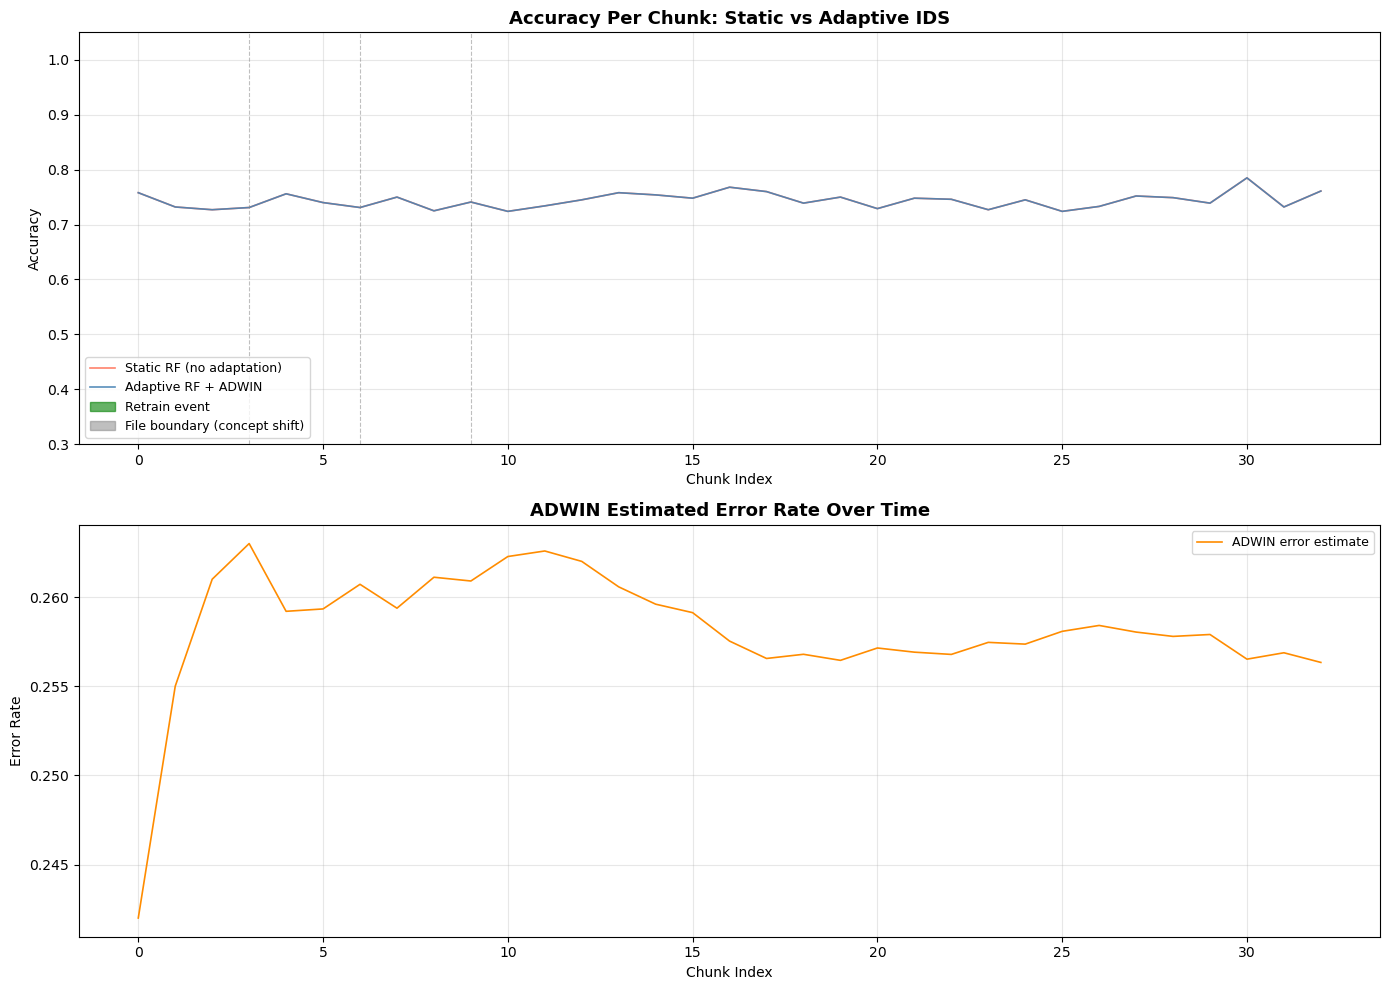

Plot saved to results/


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Panel 1: Accuracy ──────────────────────────────────────────
ax = axes[0]
ax.plot(chunk_ids, static_accs,   color='tomato',      linewidth=1.2, label='Static RF (no adaptation)', alpha=0.8)
ax.plot(chunk_ids, adaptive_accs, color='steelblue',   linewidth=1.2, label='Adaptive RF + ADWIN',       alpha=0.9)

# Mark file boundaries (simulated concept shifts)
chunks_per_file = (ROWS_PER_FILE - split) // CHUNK_SIZE  # approx
for boundary in range(1, MAX_FILES):
    ax.axvline(x=boundary * chunks_per_file, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

# Mark drift/retrain events
for d in drift_events:
    ax.axvline(x=d, color='orange', linewidth=0.5, alpha=0.3)
for r in retrain_events:
    ax.axvline(x=r, color='green', linewidth=1.0, alpha=0.6, linestyle=':')

retrain_line = mpatches.Patch(color='green',  alpha=0.6, label='Retrain event')
file_line    = mpatches.Patch(color='grey',   alpha=0.5, label='File boundary (concept shift)')
ax.legend(handles=ax.lines[:2] + [retrain_line, file_line], loc='lower left', fontsize=9)
ax.set_title('Accuracy Per Chunk: Static vs Adaptive IDS', fontsize=13, fontweight='bold')
ax.set_xlabel('Chunk Index')
ax.set_ylabel('Accuracy')
ax.set_ylim([0.3, 1.05])
ax.grid(True, alpha=0.3)

# ── Panel 2: ADWIN Error Rate ──────────────────────────────────
ax2 = axes[1]
ax2.plot(chunk_ids, error_rates, color='darkorange', linewidth=1.2, label='ADWIN error estimate')
for r in retrain_events:
    ax2.axvline(x=r, color='green', linewidth=1.0, alpha=0.6, linestyle=':')
ax2.set_title('ADWIN Estimated Error Rate Over Time', fontsize=13, fontweight='bold')
ax2.set_xlabel('Chunk Index')
ax2.set_ylabel('Error Rate')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to results/')

## 7. Summary Metrics

In [8]:
static_mean   = np.mean(static_accs)
adaptive_mean = np.mean(adaptive_accs)

print('=' * 50)
print('      SUMMARY METRICS')
print('=' * 50)
print(f'Static  RF  — mean accuracy : {static_mean:.4f}')
print(f'Adaptive RF — mean accuracy : {adaptive_mean:.4f}')
print(f'Improvement                 : {adaptive_mean - static_mean:+.4f}')
print(f'Total drift events detected : {len(drift_events)}')
print(f'Total retraining events     : {len(retrain_events)}')
print(f'Total chunks streamed       : {len(chunk_ids)}')
print('=' * 50)

      SUMMARY METRICS
Static  RF  — mean accuracy : 0.7437
Adaptive RF — mean accuracy : 0.7437
Improvement                 : +0.0000
Total drift events detected : 0
Total retraining events     : 0
Total chunks streamed       : 33


## 8. Final Classification Report (Adaptive Model)

In [13]:
# Evaluate the final adaptive model on the last file
df_last = all_dfs[-1]
X_last  = df_last.drop("Label", axis=1).values
y_last  = encoder.transform(df_last["Label"])

y_pred_adaptive = adaptive_model.predict(X_last)
y_pred_static   = static_model.predict(X_last)

# Only use labels present in this file (avoids class count mismatch)
present_labels = sorted(set(y_last))
present_names  = encoder.classes_[present_labels]

print("── Adaptive Model (final) ──")
print(classification_report(y_last, y_pred_adaptive,
                            labels=present_labels,
                            target_names=present_names,
                            zero_division=0))

print("── Static Model ──")
print(classification_report(y_last, y_pred_static,
                            labels=present_labels,
                            target_names=present_names,
                            zero_division=0))


── Adaptive Model (final) ──
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.00      0.00      0.00         3
                 BENIGN       0.69      0.91      0.79       256
       BROWSERHIJACKING       0.00      0.00      0.00         2
       COMMANDINJECTION       0.00      0.00      0.00         5
 DDOS-ACK_FRAGMENTATION       0.89      1.00      0.94        59
        DDOS-HTTP_FLOOD       0.14      0.50      0.22         2
        DDOS-ICMP_FLOOD       1.00      1.00      1.00      1589
DDOS-ICMP_FRAGMENTATION       0.99      0.99      0.99        90
      DDOS-PSHACK_FLOOD       1.00      0.99      1.00       874
       DDOS-RSTFINFLOOD       1.00      1.00      1.00       820
         DDOS-SLOWLORIS       0.00      0.00      0.00         4
DDOS-SYNONYMOUSIP_FLOOD       0.48      0.46      0.47       808
         DDOS-SYN_FLOOD       0.46      0.47      0.46       881
         DDOS-TCP_FLOOD       0.66      0.73      0.69      

## 9. False Positive Rate Comparison
FPR = FP / (FP + TN) — critical metric for IDS usability.

In [14]:
def compute_fpr(y_true, y_pred, encoder):
    """Compute macro-average false positive rate across all classes."""
    classes = list(range(len(encoder.classes_)))
    fprs = []
    for c in classes:
        y_bin_true = (y_true == c).astype(int)
        y_bin_pred = (y_pred == c).astype(int)
        cm = confusion_matrix(y_bin_true, y_bin_pred, labels=[0, 1])
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
            fprs.append(fpr)
    return np.mean(fprs)

fpr_static   = compute_fpr(y_last, y_pred_static,   encoder)
fpr_adaptive = compute_fpr(y_last, y_pred_adaptive, encoder)

print(f'Static   model FPR (macro avg): {fpr_static:.4f}')
print(f'Adaptive model FPR (macro avg): {fpr_adaptive:.4f}')

Static   model FPR (macro avg): 0.0081
Adaptive model FPR (macro avg): 0.0081


## 10. Save Results to CSV

In [15]:
results_df = pd.DataFrame({
    'chunk_id':    chunk_ids,
    'static_acc':  static_accs,
    'adaptive_acc': adaptive_accs,
    'adwin_error_rate': error_rates,
    'retrain': [1 if c in retrain_events else 0 for c in chunk_ids]
})

results_df.to_csv('../results/adaptive_ids_results.csv', index=False)
print('Results saved to ../results/adaptive_ids_results.csv')
results_df.tail(10)

Results saved to ../results/adaptive_ids_results.csv


,chunk_id,static_acc,adaptive_acc,adwin_error_rate,retrain
23,23,0.727,0.727,0.257458,0
24,24,0.745,0.745,0.257360,0
25,25,0.724,0.724,0.258077,0
26,26,0.733,0.733,0.258407,0
27,27,0.752,0.752,0.258036,0
28,28,0.749,0.749,0.257793,0
29,29,0.739,0.739,0.257900,0
30,30,0.785,0.785,0.256516,0
31,31,0.732,0.732,0.256875,0
32,32,0.761,0.761,0.256333,0
